# 🌿 NDVI Data Cube — Margaret Island, Budapest

This notebook demonstrates the concept of **satellite imagery data cubes** using Google Earth Engine.

We extract **summer NDVI (Normalized Difference Vegetation Index)** values for Margaret Island (Margit-sziget) from the past 20 years using Landsat imagery, reduced to a single mean value per year — the core idea of a data cube: a multi-temporal, multi-band raster stack queried as a structured dataset.

**NDVI = (NIR - Red) / (NIR + Red)**  
Values range from -1 (no vegetation) to +1 (dense vegetation). Healthy urban parks typically range between 0.3–0.7.

---

**Setup steps (one-time):**
1. Register for Google Earth Engine: https://earthengine.google.com/signup  
2. Create a Service Account: https://console.cloud.google.com/iam-admin/serviceaccounts  
3. Assign roles: *Earth Engine Resource Writer* + *Service Usage Consumer*  
4. Download JSON Key → add to Kaggle Secrets as `GoogleEarthEngineJSON`

In [42]:
!pip install earthengine-api

Import neccesary libraries

In [43]:
import ee
import json
import folium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

Authentication:

In [44]:
import os
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
key_json = secrets.get_secret("GoogleEarthEngineJSON")
key_data = json.loads(key_json)

credentials = ee.ServiceAccountCredentials(
    email=key_data["client_email"],
    key_data=key_json
)
ee.Initialize(credentials, project=key_data["project_id"])
print("✅ GEE authenticated:", key_data["project_id"])

✅ GEE authenticated: ancient-medium-432114-u6


## 🗺️ Define Margaret Island AOI

Margaret Island (Margit-sziget) is a ~0.96 km² island in the Danube in Budapest.  
We draw a tight polygon to exclude Danube water pixels from the NDVI statistics.

In [45]:
# Margaret Island — bounding polygon
margaret_island = ee.Geometry.Polygon([[
    [19.0435, 47.5155],   # SW
    [19.0570, 47.5155],   # SE
    [19.0570, 47.5380],   # NE
    [19.0435, 47.5380],   # NW
    [19.0435, 47.5155]    # close
]])

centroid = margaret_island.centroid().coordinates().getInfo()
print(f"✅ AOI centroid: lon={centroid[0]:.4f}, lat={centroid[1]:.4f}")
print(f"   Area ≈ {margaret_island.area().getInfo()/1e6:.3f} km²")

✅ AOI centroid: lon=19.0502, lat=47.5267
   Area ≈ 2.536 km²


## 📦 Build the NDVI Data Cube

A **data cube** in remote sensing is a 3-dimensional structure:
- **X axis** — spatial columns (longitude)
- **Y axis** — spatial rows (latitude)
- **Z axis** — time (one layer per year/season)

Each "slice" is a summer-composited Landsat image with NDVI on it.  
We reduce each slice spatially to get the mean NDVI → the temporal profile of the cube.

| Years     | Sensor              | NIR band | Red band |
|-----------|---------------------|----------|----------|
| 2004–2012 | Landsat 5 TM C2 L2  | SR_B4    | SR_B3    |
| 2013      | Landsat 7 ETM+ C2 L2| SR_B4    | SR_B3    |
| 2014–2024 | Landsat 8 OLI C2 L2 | SR_B5    | SR_B4    |

In [46]:
def mask_landsat_clouds(image):
    """QA_PIXEL cloud + shadow mask for Landsat C2 L2."""
    qa = image.select('QA_PIXEL')
    cloud  = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud.And(shadow))

def compute_ndvi_l57(image):
    """NDVI for Landsat 5/7 TM — C2 L2 surface reflectance (NIR=SR_B4, Red=SR_B3)."""
    return image.addBands(
        image.normalizedDifference(['SR_B4', 'SR_B3']).rename('NDVI'))

def compute_ndvi_l8(image):
    """NDVI for Landsat 8/9 OLI — C2 L2 surface reflectance (NIR=SR_B5, Red=SR_B4)."""
    return image.addBands(
        image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI'))

print("✅ Helper functions ready.")

✅ Helper functions ready.


In [47]:
def get_summer_ndvi(year):
    """
    One data cube slice: summer median NDVI for Margaret Island.
    
    Returns a server-side ee.Number (or ee.Number(None) when the
    collection is empty for that year — safe to .getInfo()).
    """
    start = f'{year}-06-01'
    end   = f'{year}-08-31'

    if year <= 2012:
        cid, ndvi_fn = 'LANDSAT/LT05/C02/T1_L2', compute_ndvi_l57
    elif year == 2013:
        cid, ndvi_fn = 'LANDSAT/LE07/C02/T1_L2', compute_ndvi_l57
    else:
        cid, ndvi_fn = 'LANDSAT/LC08/C02/T1_L2', compute_ndvi_l8

    col = (ee.ImageCollection(cid)
           .filterBounds(margaret_island)
           .filterDate(start, end)
           .filter(ee.Filter.lt('CLOUD_COVER', 40))   # relaxed to 40 %
           .map(mask_landsat_clouds)
           .map(ndvi_fn))

    # Guard: if collection is empty, return null instead of crashing
    size = col.size()
    composite = col.select('NDVI').median()

    stats = composite.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=margaret_island,
        scale=30,
        maxPixels=1e9
    )

    # ee.Algorithms.If prevents server-side KeyError when dict is empty
    ndvi_val = ee.Algorithms.If(
        size.gt(0),
        stats.get('NDVI'),   # normal path
        None                 # fallback when no scenes found
    )
    return ndvi_val


# ── BUILD THE DATA CUBE (2004 – 2024) ─────────────────────────────────
years = list(range(2004, 2025))

print("⏳ Querying GEE for 21 annual summer NDVI cube slices …")
ndvi_ee_objects = [get_summer_ndvi(y) for y in years]

# Resolve server-side objects → local Python values
# Wrap each individually so one bad year doesn't kill the whole loop
ndvi_values = []
for y, obj in zip(years, ndvi_ee_objects):
    try:
        val = obj.getInfo()
    except Exception as e:
        print(f"  ⚠️  {y}: getInfo failed ({e}) — marking as NaN")
        val = None
    ndvi_values.append(val)

import pandas as pd
import numpy as np

df = pd.DataFrame({'year': years, 'mean_ndvi': ndvi_values})
df['mean_ndvi'] = pd.to_numeric(df['mean_ndvi'], errors='coerce')

nan_count = df['mean_ndvi'].isna().sum()
if nan_count:
    print(f"\n⚠️  {nan_count} year(s) returned NaN (no cloud-free scenes found):")
    print("  ", list(df.loc[df['mean_ndvi'].isna(), 'year']))

print("\n📊 Margaret Island — Summer NDVI Data Cube (2004–2024)")
print("─" * 44)
print(df.to_string(index=False))
print(f"\n20-yr mean NDVI : {df['mean_ndvi'].mean():.4f}")
print(f"Minimum         : {df['mean_ndvi'].min():.4f}  "
      f"({int(df.loc[df['mean_ndvi'].idxmin(), 'year'])})")
print(f"Maximum         : {df['mean_ndvi'].max():.4f}  "
      f"({int(df.loc[df['mean_ndvi'].idxmax(), 'year'])})")

⏳ Querying GEE for 21 annual summer NDVI cube slices …

⚠️  2 year(s) returned NaN (no cloud-free scenes found):
   [2012, 2019]

📊 Margaret Island — Summer NDVI Data Cube (2004–2024)
────────────────────────────────────────────
 year  mean_ndvi
 2004   0.116931
 2005   0.144070
 2006   0.134791
 2007   0.124181
 2008   0.128666
 2009   0.119076
 2010   0.136043
 2011   0.138717
 2012        NaN
 2013   0.130589
 2014   0.142398
 2015   0.137799
 2016   0.115124
 2017   0.133879
 2018   0.148037
 2019        NaN
 2020   0.140714
 2021   0.129634
 2022   0.141190
 2023   0.139458
 2024   0.132088

20-yr mean NDVI : 0.1333
Minimum         : 0.1151  (2016)
Maximum         : 0.1480  (2018)


## 📈 Visualise the NDVI Time Series

Plot the temporal profile extracted by querying the data cube along the time axis.  
A declining trend may indicate urban heat stress or drought years; a stable/rising trend = healthy vegetation.

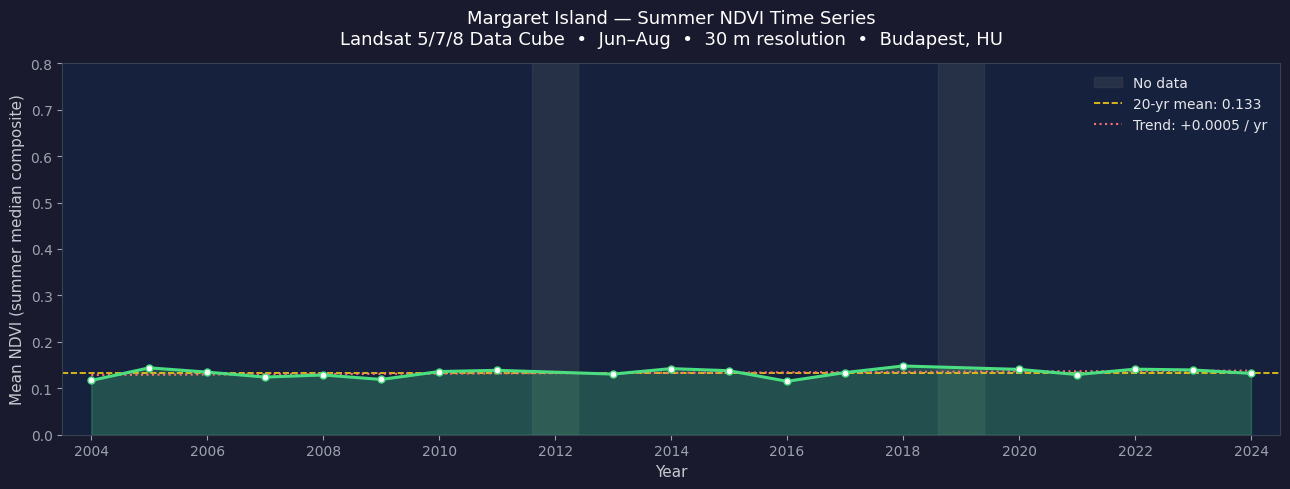

✅ Chart saved (19 years with valid data).


In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

valid = df.dropna(subset=['mean_ndvi']).copy()

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

ax.fill_between(valid['year'], valid['mean_ndvi'], alpha=0.25, color='#4ade80', zorder=1)
ax.plot(valid['year'], valid['mean_ndvi'],
        color='#4ade80', linewidth=2.2, marker='o',
        markersize=5, markerfacecolor='white', markeredgecolor='#4ade80', zorder=3)

# Mark NaN years (no data) as vertical grey bands
for y in df.loc[df['mean_ndvi'].isna(), 'year']:
    ax.axvspan(y - 0.4, y + 0.4, color='#374151', alpha=0.5, zorder=0, label='No data')

mean_val = valid['mean_ndvi'].mean()
ax.axhline(mean_val, color='#facc15', linewidth=1.2, linestyle='--',
           label=f'20-yr mean: {mean_val:.3f}', zorder=2)

m_coef, b_coef = np.polyfit(valid['year'], valid['mean_ndvi'], 1)
ax.plot(valid['year'], m_coef * valid['year'].values + b_coef,
        color='#f87171', linewidth=1.5, linestyle=':',
        label=f'Trend: {m_coef:+.4f} / yr', zorder=2)

ax.set_xlabel('Year', color='#c8c8d0', fontsize=11)
ax.set_ylabel('Mean NDVI (summer median composite)', color='#c8c8d0', fontsize=11)
ax.set_title('Margaret Island — Summer NDVI Time Series\n'
             'Landsat 5/7/8 Data Cube  •  Jun–Aug  •  30 m resolution  •  Budapest, HU',
             color='white', fontsize=13, pad=14)
ax.tick_params(colors='#9ca3af')
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
for sp in ax.spines.values():
    sp.set_edgecolor('#374151')

# De-duplicate legend entries (NaN band may appear multiple times)
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    seen.setdefault(l, h)
ax.legend(seen.values(), seen.keys(), frameon=False, labelcolor='#e5e7eb', fontsize=10)

ax.set_xlim(df['year'].min() - 0.5, df['year'].max() + 0.5)
ax.set_ylim(0, 0.8)

plt.tight_layout()
plt.savefig('/kaggle/working/margaret_island_ndvi_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved ({len(valid)} years with valid data).")

⏬ Downloading NDVI GeoTIFF …
⏬ Downloading RGB GeoTIFF …
✅ NDVI TIF: 10.0 KB
✅ RGB  TIF: 22.5 KB


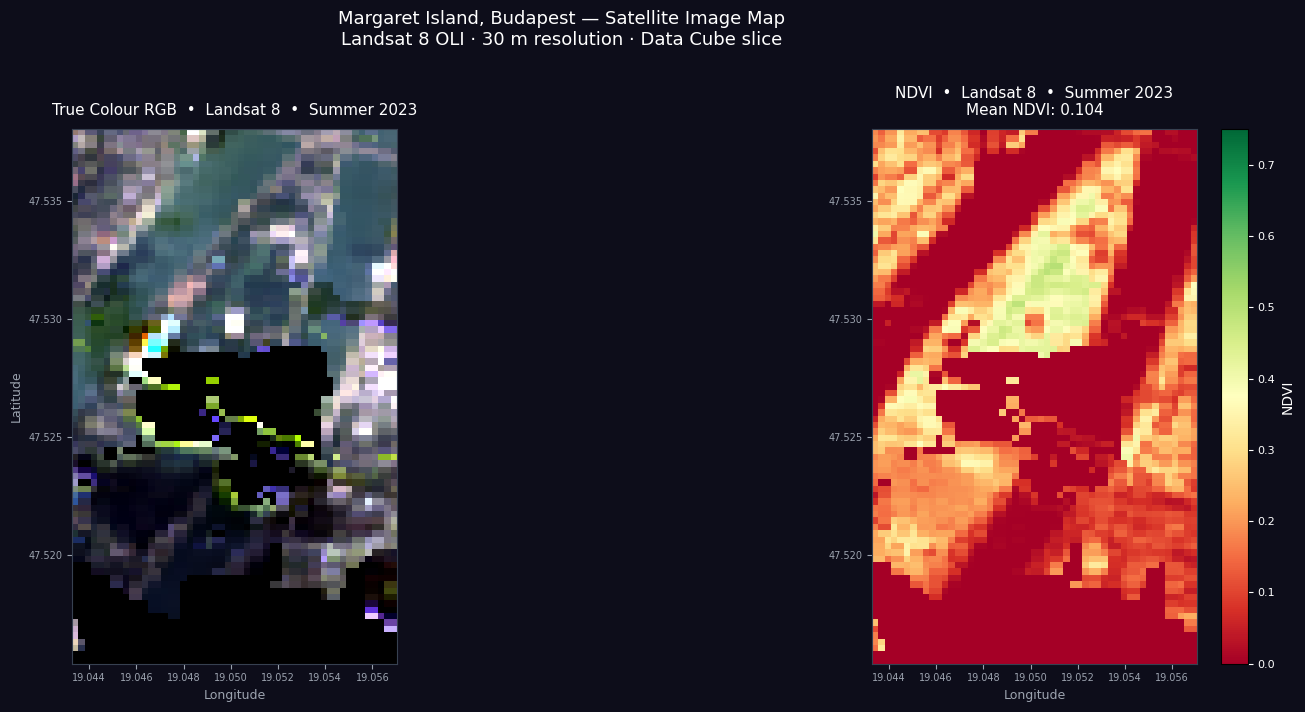

✅ Map saved: /kaggle/working/margaret_island_satellite_map.png


In [49]:
!pip install rasterio --quiet

import requests, zipfile, io, os
import numpy as np
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

latest_year = 2023

# ── Build the NDVI composite  ────────────────────────
col_map = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
           .filterBounds(margaret_island)
           .filterDate(f'{latest_year}-06-01', f'{latest_year}-08-31')
           .filter(ee.Filter.lt('CLOUD_COVER', 40))
           .map(mask_landsat_clouds)
           .map(compute_ndvi_l8))

ndvi_composite = col_map.select('NDVI').median().clip(margaret_island)
rgb_composite  = (col_map
                  .select(['SR_B4', 'SR_B3', 'SR_B2'])
                  .median()
                  .clip(margaret_island))

# ── Download GeoTIFF directly into memory via getDownloadURL ─────────
# This is authenticated via your service account — no browser involved
region_coords = margaret_island.getInfo()['coordinates']

ndvi_url = ndvi_composite.getDownloadURL({
    'name':   'ndvi',
    'bands':  ['NDVI'],
    'region': region_coords,
    'scale':  30,       # 30 m Landsat native resolution
    'format': 'GEO_TIFF'
})

rgb_url = rgb_composite.getDownloadURL({
    'name':   'rgb',
    'bands':  ['SR_B4', 'SR_B3', 'SR_B2'],
    'region': region_coords,
    'scale':  30,
    'format': 'GEO_TIFF'
})

print("⏬ Downloading NDVI GeoTIFF …")
r_ndvi = requests.get(ndvi_url, timeout=120)
r_ndvi.raise_for_status()

print("⏬ Downloading RGB GeoTIFF …")
r_rgb  = requests.get(rgb_url,  timeout=120)
r_rgb.raise_for_status()

# Save locally
ndvi_path = '/kaggle/working/ndvi_margaret.tif'
rgb_path  = '/kaggle/working/rgb_margaret.tif'
with open(ndvi_path, 'wb') as f: f.write(r_ndvi.content)
with open(rgb_path,  'wb') as f: f.write(r_rgb.content)
print(f"✅ NDVI TIF: {os.path.getsize(ndvi_path)/1024:.1f} KB")
print(f"✅ RGB  TIF: {os.path.getsize(rgb_path )/1024:.1f} KB")

# ── Read & display ────────────────────────────────────────────────────
with rasterio.open(ndvi_path) as src_ndvi:
    ndvi_arr = src_ndvi.read(1).astype(float)
    ndvi_arr[ndvi_arr < -1] = np.nan   # mask nodata
    extent_ndvi = [src_ndvi.bounds.left, src_ndvi.bounds.right,
                   src_ndvi.bounds.bottom, src_ndvi.bounds.top]
    transform = src_ndvi.transform

with rasterio.open(rgb_path) as src_rgb:
    r = src_rgb.read(1).astype(float)
    g = src_rgb.read(2).astype(float)
    b = src_rgb.read(3).astype(float)
    # Normalise C2 L2 SR values (0–65535 range, typical land ~7000–15000)
    def norm(band):
        p2, p98 = np.nanpercentile(band[band > 0], [2, 98])
        return np.clip((band - p2) / (p98 - p2), 0, 1)
    rgb_arr = np.dstack([norm(r), norm(g), norm(b)])
    extent_rgb = [src_rgb.bounds.left, src_rgb.bounds.right,
                  src_rgb.bounds.bottom, src_rgb.bounds.top]

# ── Plot side-by-side ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.patch.set_facecolor('#0d0d1a')

cmap_ndvi = plt.cm.RdYlGn
cmap_ndvi.set_bad(color='#1a1a2e')

# Left: True Colour RGB
axes[0].imshow(rgb_arr, extent=extent_rgb, origin='upper', aspect='equal')
axes[0].set_title(f'True Colour RGB  •  Landsat 8  •  Summer {latest_year}',
                  color='white', fontsize=11, pad=10)
axes[0].set_xlabel('Longitude', color='#9ca3af', fontsize=9)
axes[0].set_ylabel('Latitude',  color='#9ca3af', fontsize=9)
axes[0].tick_params(colors='#9ca3af', labelsize=7)
for sp in axes[0].spines.values(): sp.set_edgecolor('#374151')

# Right: NDVI
im = axes[1].imshow(ndvi_arr, cmap=cmap_ndvi, vmin=0.0, vmax=0.75,
                    extent=extent_ndvi, origin='upper', aspect='equal')
axes[1].set_title(f'NDVI  •  Landsat 8  •  Summer {latest_year}\n'
                  f'Mean NDVI: {np.nanmean(ndvi_arr):.3f}',
                  color='white', fontsize=11, pad=10)
axes[1].set_xlabel('Longitude', color='#9ca3af', fontsize=9)
axes[1].tick_params(colors='#9ca3af', labelsize=7)
for sp in axes[1].spines.values(): sp.set_edgecolor('#374151')

# Colourbar
cbar = fig.colorbar(im, ax=axes[1], fraction=0.035, pad=0.03)
cbar.set_label('NDVI', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white', labelsize=8)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
cbar.ax.set_facecolor('#1a1a2e')

fig.suptitle('Margaret Island, Budapest — Satellite Image Map\n'
             'Landsat 8 OLI · 30 m resolution · Data Cube slice',
             color='white', fontsize=13, y=1.01)

plt.tight_layout()
out_map = '/kaggle/working/margaret_island_satellite_map.png'
plt.savefig(out_map, dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print(f"✅ Map saved: {out_map}")

In [50]:
import requests, os
import numpy as np
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import folium
from IPython.display import IFrame, display
from PIL import Image
import io, base64

# ── Colour map: NDVI → RGBA PNG (used by ImageOverlay) ───────────────
ndvi_cmap = plt.cm.RdYlGn

def ndvi_array_to_png_base64(ndvi_arr, vmin=0.0, vmax=0.75):
    """Convert a 2-D NDVI array to a base64-encoded RGBA PNG for Folium."""
    normed = np.clip((ndvi_arr - vmin) / (vmax - vmin), 0, 1)
    rgba   = ndvi_cmap(normed)           # shape (H, W, 4)
    # Make nodata (NaN) fully transparent
    rgba[np.isnan(ndvi_arr), 3] = 0.0
    img_uint8 = (rgba * 255).astype(np.uint8)
    pil_img   = Image.fromarray(img_uint8, mode='RGBA')
    buf = io.BytesIO()
    pil_img.save(buf, format='PNG')
    b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    return f'data:image/png;base64,{b64}'

# ── Download NDVI GeoTIFF for every year ─────────────────────────────
region_coords = margaret_island.getInfo()['coordinates']

# We'll create layers for all years that have valid NDVI data
valid_years = list(df.dropna(subset=['mean_ndvi'])['year'].astype(int))
print(f"📦 Downloading NDVI tiles for {len(valid_years)} years: {valid_years}\n")

year_layers = {}   # year → {'arr': ndarray, 'bounds': (S,W,N,E)}

for year in valid_years:
    # Choose correct collection per sensor
    if year <= 2012:
        cid, ndvi_fn = 'LANDSAT/LT05/C02/T1_L2', compute_ndvi_l57
    elif year == 2013:
        cid, ndvi_fn = 'LANDSAT/LE07/C02/T1_L2', compute_ndvi_l57
    else:
        cid, ndvi_fn = 'LANDSAT/LC08/C02/T1_L2', compute_ndvi_l8

    col_y = (ee.ImageCollection(cid)
             .filterBounds(margaret_island)
             .filterDate(f'{year}-06-01', f'{year}-08-31')
             .filter(ee.Filter.lt('CLOUD_COVER', 40))
             .map(mask_landsat_clouds)
             .map(ndvi_fn))

    ndvi_img = col_y.select('NDVI').median().clip(margaret_island)

    url = ndvi_img.getDownloadURL({
        'name':   f'ndvi_{year}',
        'bands':  ['NDVI'],
        'region': region_coords,
        'scale':  30,
        'format': 'GEO_TIFF'
    })

    try:
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        tif_path = f'/kaggle/working/ndvi_{year}.tif'
        with open(tif_path, 'wb') as f:
            f.write(r.content)

        with rasterio.open(tif_path) as src:
            arr = src.read(1).astype(float)
            arr[arr < -1] = np.nan
            # Get geographic bounds in WGS84 (lat/lon)
            bounds_wgs84 = transform_bounds(
                src.crs, 'EPSG:4326',
                src.bounds.left, src.bounds.bottom,
                src.bounds.right, src.bounds.top
            )  # (west, south, east, north)

        year_layers[year] = {
            'arr':    arr,
            'bounds': bounds_wgs84,   # (W, S, E, N)
            'mean':   float(np.nanmean(arr))
        }
        print(f"  ✅ {year}  mean NDVI={year_layers[year]['mean']:.3f}  "
              f"shape={arr.shape}")

    except Exception as e:
        print(f"  ⚠️  {year}: download failed — {e}")

print(f"\n✅ {len(year_layers)} years downloaded successfully.")

📦 Downloading NDVI tiles for 19 years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2013, 2014, 2015, 2016, 2017, 2018, 2020, 2021, 2022, 2023, 2024]

  ✅ 2004  mean NDVI=0.116  shape=(84, 51)
  ✅ 2005  mean NDVI=0.144  shape=(84, 51)
  ✅ 2006  mean NDVI=0.134  shape=(84, 51)
  ✅ 2007  mean NDVI=0.124  shape=(84, 51)
  ✅ 2008  mean NDVI=0.129  shape=(84, 51)
  ✅ 2009  mean NDVI=0.119  shape=(84, 51)
  ✅ 2010  mean NDVI=0.136  shape=(84, 51)
  ✅ 2011  mean NDVI=0.138  shape=(84, 51)
  ✅ 2013  mean NDVI=0.131  shape=(84, 51)
  ✅ 2014  mean NDVI=0.142  shape=(84, 51)
  ✅ 2015  mean NDVI=0.137  shape=(84, 51)
  ✅ 2016  mean NDVI=0.115  shape=(84, 51)
  ✅ 2017  mean NDVI=0.133  shape=(84, 51)
  ✅ 2018  mean NDVI=0.147  shape=(84, 51)
  ✅ 2020  mean NDVI=0.123  shape=(84, 51)
  ✅ 2021  mean NDVI=0.129  shape=(84, 51)
  ✅ 2022  mean NDVI=0.141  shape=(84, 51)
  ✅ 2023  mean NDVI=0.104  shape=(84, 51)
  ✅ 2024  mean NDVI=0.132  shape=(84, 51)

✅ 19 years downloaded successfully.


✅ Multi-year map saved: /kaggle/working/margaret_island_ndvi_multiyear.html
   19 year layers: 2004–2024


/tmp/ipykernel_57/3265236130.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img   = Image.fromarray(img_uint8, mode='RGBA')



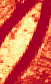
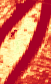
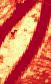
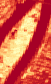
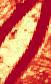
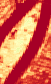
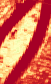
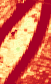
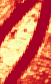
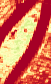
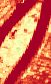
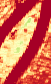
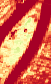
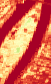
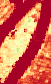
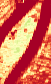
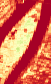
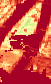
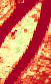

In [51]:
# ── Build Folium map with one ImageOverlay layer per year ─────────────
m = folium.Map(
    location=[47.527, 19.049],
    zoom_start=15,
    tiles='CartoDB dark_matter'
)

# Add each year as a separate toggleable layer (all hidden by default
# except the most recent)
sorted_years = sorted(year_layers.keys())

for i, year in enumerate(sorted_years):
    data     = year_layers[year]
    W, S, E, N = data['bounds']
    png_b64  = ndvi_array_to_png_base64(data['arr'])
    mean_val = data['mean']

    # Show only the latest year by default; rest toggled off
    show_layer = (year == sorted_years[-1])

    folium.raster_layers.ImageOverlay(
        image=png_b64,
        bounds=[[S, W], [N, E]],
        opacity=0.85,
        name=f'{year}  (mean NDVI: {mean_val:.3f})',
        show=show_layer,
        interactive=False,
        zindex=i
    ).add_to(m)

# Island AOI outline
folium.GeoJson(
    margaret_island.getInfo(),
    name='Margaret Island AOI',
    style_function=lambda _: {
        'color': '#facc15', 'weight': 2.5, 'fillOpacity': 0.0
    },
    show=True
).add_to(m)

# ── HTML colourbar legend ─────────────────────────────────────────────
legend_html = """
<div style="position:fixed; bottom:30px; right:15px; z-index:9999;
            background:rgba(13,13,26,0.88); padding:12px 16px;
            border-radius:8px; color:white; font-size:11px;
            font-family:monospace; line-height:1.6; border:1px solid #374151;">
  <b style="font-size:12px;">NDVI</b><br>
  <span style="color:#1a9850">■</span> 0.75  Dense vegetation<br>
  <span style="color:#91cf60">■</span> 0.55  Moderate<br>
  <span style="color:#fee08b">■</span> 0.35  Sparse<br>
  <span style="color:#fc8d59">■</span> 0.15  Bare soil<br>
  <span style="color:#d73027">■</span> 0.00  No vegetation<br>
  <hr style="border-color:#374151; margin:6px 0">
  <span style="color:#9ca3af; font-size:10px;">Toggle years in layer control ↗</span>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Layer control — collapsed=False so user sees all year layers
folium.LayerControl(collapsed=False, position='topright').add_to(m)

# ── Save and display ──────────────────────────────────────────────────
map_path = '/kaggle/working/margaret_island_ndvi_multiyear.html'
m.save(map_path)
print(f"✅ Multi-year map saved: {map_path}")
print(f"   {len(sorted_years)} year layers: {sorted_years[0]}–{sorted_years[-1]}")

from IPython.display import HTML, display

with open(map_path, 'r', encoding='utf-8') as f:
    map_html = f.read()

# Wrap in a sized div so the map has a fixed height in the notebook cell
display(HTML(f'<div style="width:100%;height:580px;overflow:hidden">{map_html}</div>'))

In [52]:
df['island']       = 'Margaret Island'
df['sensor']       = df['year'].apply(
    lambda y: 'Landsat 5 TM' if y <= 2012
    else ('Landsat 7 ETM+' if y == 2013 else 'Landsat 8 OLI'))
df['season']       = 'Summer (Jun–Aug)'
df['resolution_m'] = 30

df.to_csv('/kaggle/working/margaret_island_ndvi_cube.csv', index=False)
print("✅ Saved: /kaggle/working/margaret_island_ndvi_cube.csv")
print(df[['year','sensor','mean_ndvi']].to_string(index=False))

✅ Saved: /kaggle/working/margaret_island_ndvi_cube.csv
 year         sensor  mean_ndvi
 2004   Landsat 5 TM   0.116931
 2005   Landsat 5 TM   0.144070
 2006   Landsat 5 TM   0.134791
 2007   Landsat 5 TM   0.124181
 2008   Landsat 5 TM   0.128666
 2009   Landsat 5 TM   0.119076
 2010   Landsat 5 TM   0.136043
 2011   Landsat 5 TM   0.138717
 2012   Landsat 5 TM        NaN
 2013 Landsat 7 ETM+   0.130589
 2014  Landsat 8 OLI   0.142398
 2015  Landsat 8 OLI   0.137799
 2016  Landsat 8 OLI   0.115124
 2017  Landsat 8 OLI   0.133879
 2018  Landsat 8 OLI   0.148037
 2019  Landsat 8 OLI        NaN
 2020  Landsat 8 OLI   0.140714
 2021  Landsat 8 OLI   0.129634
 2022  Landsat 8 OLI   0.141190
 2023  Landsat 8 OLI   0.139458
 2024  Landsat 8 OLI   0.132088


*Here we have to mention that we cheated a bit, because the sensor set of Landsat 5, Landsat 7, and Landsat 8 are a bit different, so it should be arranged first if we want to use it for high precision measurements.* 

*USGS Collection 2 Level-2 processing already standardises radiometry, geometry, and per-scene quality, making cross-sensor comparisons analysis-ready for most applications without additional harmonisation. In practice, residual differences between the sensors are small and mainly noticeable only in very sparse vegetation areas. However, for research requiring high precision — such as detecting subtle long-term changes — dedicated inter-sensor harmonisation methods do exist and are recommended.* 

*More:* 
- https://www.sciencedirect.com/science/article/abs/pii/S0034425721002376
- https://www.esri.com/arcgis-blog/products/product/imagery/band-combinations-for-landsat-8
- https://www.usgs.gov/faqs/what-are-band-designations-landsat-satellites

## * 📚 Data Cube Concept Summary

| Dimension | In this notebook |
|---|---|
| **X / Y (space)** | All 30 m Landsat pixels over Margaret Island |
| **Z (time)** | 21 annual summer composites, 2004–2024 |
| **Bands** | NDVI derived from NIR & Red |
| **Spatial reduction** | `reduceRegion(mean)` → 1 scalar per year |

**Key GEE operations used:**
- `filterDate()` — select time slices of the cube
- `map(ndvi_fn)` — apply band math across all slices
- `.median()` — intra-season cloud-free composite → clean cube slice
- `reduceRegion(mean)` — spatial aggregation, exposing the time axis

A full, unreduced data cube retains all spatial pixels across all time steps.  
This notebook queries the cube along **both axes** simultaneously (space → mean, time → profile).